# Response / reward PSTH for opto-tagged units

Trial-outcome PSTH comparisons for the **opto-tagged units** (same selection as
`raster_psth_QLearning_tagged_units.ipynb`):

- **Response vs no-response** — per-unit PSTH, population average, per-unit
  scatter, paired Wilcoxon signed-rank test, and a trial-count-matched control.
- **Reward vs no-reward** — per-unit raster/PSTH and population average.

Setup (environment, tagged-unit selection, session resources) mirrors the latent
raster notebook so this notebook runs standalone.

In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")

✅ Analysis modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [2]:
# =============================================================================
# 2. CONFIG
# =============================================================================
from pathlib import Path

# --- Session identifiers -----------------------------------------------------
session_date = '863973_2026-08-25_14-18-29'
ephys_session = None   # None -> auto-discover from the PSTH Zarr in step 4

# --- Paths (match raster_worker.py conventions) ------------------------------
PSTH_DIR = Path("/root/capsule/scratch/psth_results")
RESULTS_DIR = Path("/root/capsule/scratch/behavior_summary")
metrics_csv_path = f"/root/capsule/scratch/opto_tagging/metrics_{session_date}.csv"
OUTDIR = Path(f"/root/capsule/scratch/raster_plot_tagged/{session_date}")

# --- Raster / PSTH alignment -------------------------------------------------
ALIGN_TO = "go_cue"
TIME_WIN = (-3, 4)

# --- Opto-tag condition + selection (must match save_tagged_unit_figures) ----
#   (target_power, location_tag, laser_name, cycle_duration, frequency, pulse_duration)
target_cond = (5.0, 1.0, "Laser_1", 1.0, 10.0, 0.05)
SELECT_PULSE_INDEX = -1   # -1 = pooled over all pulses in the train

print(f"Metrics CSV : {metrics_csv_path}")
print(f"Output dir  : {OUTDIR}")

Metrics CSV : /root/capsule/scratch/opto_tagging/metrics_863973_2026-08-25_14-18-29.csv
Output dir  : /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29


In [3]:
# =============================================================================
# 3. TAGGED UNITS (re-select from the saved opto-tagging metrics CSV)
# =============================================================================
# compute_tagging_metrics only ran on QC-passing units, so every unit_id in the
# metrics table already passed QC -> selecting tagged==True is sufficient.
import re
import pandas as pd
from ast import literal_eval
from optical_tagging import select_tagged_units

metrics_df = pd.read_csv(metrics_csv_path)

tagged_df = select_tagged_units(
    metrics_df,
    alpha=0.05,
    effect_ratio=2.0,
    min_abs_increase=0.0,
    min_reliability=0.2,
    max_latency=0.006,
    max_jitter=0.003,
    correction="fdr_bh",
)

# `condition` is a string after the CSV round-trip. Older CSVs may contain numpy
# scalar wrappers like "np.float64(1.0)"; strip them before parsing.
def as_tuple(c):
    if isinstance(c, str):
        c = re.sub(r"np\.\w+\(([^()]*)\)", r"\1", c)
        try:
            c = literal_eval(c)
        except (ValueError, SyntaxError):
            return None
    return tuple(c) if isinstance(c, (tuple, list)) else None

# Match the condition on every field EXCEPT laser_name (index 2).
IGNORE_IDX = 2
match_idx = [i for i in range(6) if i != IGNORE_IDX]

def matches_ignore_laser(c):
    c = as_tuple(c)
    if c is None or len(c) != 6:
        return False
    return all(c[i] == target_cond[i] for i in match_idx)

cond_mask = tagged_df["condition"].apply(matches_ignore_laser)
pulse_mask = tagged_df["pulse_index"] == SELECT_PULSE_INDEX
sigrows = tagged_df[cond_mask & pulse_mask & (tagged_df["tagged"] == True)]

tagged_units = sorted(int(u) for u in sigrows["unit_id"].unique())
print(f"Condition (laser_name ignored): {target_cond} | pulse_index={SELECT_PULSE_INDEX}")
print(f"Tagged units ({len(tagged_units)}): {tagged_units}")
if not tagged_units:
    raise ValueError(
        "No tagged units found for this condition/selection. "
        "Check that target_cond matches a condition present in the metrics CSV."
    )

Condition (laser_name ignored): (5.0, 1.0, 'Laser_1', 1.0, 10.0, 0.05) | pulse_index=-1
Tagged units (122): [310, 311, 748, 752, 759, 788, 792, 2023, 2025, 2036, 2059, 2109, 2115, 2116, 2149, 2185, 2200, 2203, 2208, 2209, 2212, 2215, 2225, 2230, 2233, 2238, 2239, 2240, 2241, 2245, 2250, 2255, 2257, 2259, 2263, 2264, 2272, 2277, 2284, 2288, 2289, 2296, 2300, 2303, 2314, 2315, 2317, 2322, 2324, 2326, 2331, 2334, 2344, 2366, 2558, 2586, 2587, 2588, 2609, 2613, 2629, 2630, 2634, 2685, 2689, 2692, 2706, 2732, 2735, 2803, 2811, 2826, 2845, 2946, 2947, 2960, 2983, 3000, 3014, 3020, 3023, 3031, 3032, 3033, 3258, 3269, 3326, 3329, 3335, 3336, 3385, 3393, 3400, 3403, 3453, 3467, 3502, 3603, 3620, 3629, 3656, 3663, 3665, 3673, 3696, 3700, 3705, 3718, 3736, 3757, 3809, 3814, 4045, 4062, 4077, 4106, 4159, 4227, 4270, 4273, 4280, 4320]


In [4]:
# =============================================================================
# 4. LOAD SESSION RESOURCES (Zarr PSTH, behavior summary, trials)
# =============================================================================
import numpy as np
from general_utils import smart_read_csv
from behavior_utils import find_trials, get_fitted_model_names
from nwb_utils import NWBUtils
from create_psth import load_zarr

# Auto-discover the full sorted session name from the PSTH Zarr if not set.
if ephys_session is None:
    cands = sorted(PSTH_DIR.glob(f"ecephys_{session_date}_sorted*_0.2s.zarr"))
    if not cands:
        raise FileNotFoundError(
            f"No PSTH Zarr matching ecephys_{session_date}_sorted*_0.2s.zarr in {PSTH_DIR}"
        )
    ephys_session = cands[0].name[: -len("_0.2s.zarr")]
print(f"ephys_session: {ephys_session}")

zarr_path = PSTH_DIR / f"{ephys_session}_0.2s.zarr"
beh_csv = RESULTS_DIR / f"behavior_summary-{ephys_session}.csv"
assert zarr_path.exists(), f"Zarr not found: {zarr_path}"
assert beh_csv.exists(), f"Behavior CSV not found: {beh_csv}"

nwb, _ = NWBUtils.combine_nwb(session_name=ephys_session)
psth = load_zarr(str(zarr_path))
beh = smart_read_csv(str(beh_csv))
trials = np.asarray(find_trials(nwb, "response"))
print(f"n_trials (response): {len(trials)}")

# Optogenetics (laser-on) trials -> excluded from the raster/PSTH by default.
if "laser_on_trial" in nwb.trials.colnames:
    laser_on = np.asarray(nwb.trials["laser_on_trial"][:])
    opto_trial_ids = np.where(laser_on == 1)[0].astype(np.int64)
else:
    opto_trial_ids = np.array([], dtype=np.int64)
print(f"opto (laser-on) trials: {len(opto_trial_ids)}")

import matplotlib.pyplot as plt
OUTDIR.mkdir(parents=True, exist_ok=True)

ephys_session: ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54
Found ephys NWB: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_863973_2026-08-25_14-18-29_sorted_2026-09-09_23-04-54/nwb/ecephys_863973_2026-08-25_14-18-29_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/863973_2026-08-25_14-18-29.nwb
Successfully appended units table to behavior NWB.
n_trials (response): 420
opto (laser-on) trials: 86


# 6. PSTH: response vs no-response trials (tagged units)

For each opto-tagged unit, overlay the mean ± SEM PSTH for **response** trials
(`animal_response != 2`) and **no-response** trials (`animal_response == 2`),
aligned to the same event/window as the latent rasters.

In [ ]:
# =============================================================================
# 6. PSTH: response vs no-response trials (tagged units only)
# =============================================================================
from plot_raster import plot_psth_raster_for_units

RESP_OUTDIR = OUTDIR / "response_vs_noresponse"
RESP_OUTDIR.mkdir(parents=True, exist_ok=True)

plot_psth_raster_for_units(
    source=psth,
    unit_ids=tagged_units,                      # restrict to opto-tagged units
    trial_types=["response", "no_response"],    # two PSTH groups
    nwb_data=nwb,                               # needed to look up trial ids
    exclude_trial_ids=opto_trial_ids,           # drop laser-on trials (default on)
    align_to_event=ALIGN_TO,
    time_window=TIME_WIN,
    plot_type="mean",                          # mean +/- SEM per group
    group_labels=["response", "no-response"],
    figsize=(6, 4),
    save_path=str(RESP_OUTDIR),
    show=False,
)
print(f"PSTH response vs no-response saved for {len(tagged_units)} units -> {RESP_OUTDIR}")

# 7. Population-average PSTH: response vs no-response (all tagged units)

A single figure overlaying the **mean ± SEM PSTH across all tagged units** for
**response** vs **no-response** trials. For each unit we first average across
trials within a group, then average those per-unit means across units (SEM is
computed across units). Optogenetics (laser-on) trials are excluded by default.

In [ ]:
# =============================================================================
# 7. POPULATION-AVERAGE PSTH: response vs no-response (all tagged units)
# =============================================================================
from create_psth import load_psth_raster_subset

# Toggle: drop optogenetics (laser-on) trials from both groups.
EXCLUDE_OPTO = True
_opto_excl = opto_trial_ids if EXCLUDE_OPTO else np.array([], dtype=np.int64)

# Load PSTH for the tagged units (all trials), aligned to the same event/window.
pop_psth, _ = load_psth_raster_subset(
    psth,
    trial_ids=None,
    unit_ids=tagged_units,
    align_to_event=ALIGN_TO,
    time_window=TIME_WIN,
    consolidated=True,
)

trial_dim = next(d for d in pop_psth.dims if d.startswith("trial_"))
trial_coord = next(c for c in pop_psth.coords if c.startswith("trial_index_"))
times = pop_psth.coords["time"].values
avail_ids = np.asarray(pop_psth.coords[trial_coord].values, dtype=np.int64)
n_units = int(pop_psth.sizes["unit"])

# Trial groups: response / no-response, opto (laser-on) trials excluded if EXCLUDE_OPTO.
GROUPS = {
    "response": np.asarray(find_trials(nwb, "response"), dtype=np.int64),
    "no-response": np.asarray(find_trials(nwb, "no_response"), dtype=np.int64),
}
GROUPS = {k: np.setdiff1d(v, _opto_excl, assume_unique=False) for k, v in GROUPS.items()}
GROUPS = {k: np.intersect1d(v, avail_ids, assume_unique=False) for k, v in GROUPS.items()}

fig, ax = plt.subplots(figsize=(6, 4))
group_colors = {"response": "tab:blue", "no-response": "tab:orange"}

for label, tids in GROUPS.items():
    if tids.size == 0:
        print(f"skip: {label} (no trials)")
        continue
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})          # dims: unit, trial, time
    per_unit_mean = sub.mean(dim=trial_dim)        # dims: unit, time
    pop_mean = per_unit_mean.mean(dim="unit").values
    pop_sem = (
        per_unit_mean.std(dim="unit").values / np.sqrt(max(n_units, 1))
    )
    color = group_colors.get(label, None)
    ax.plot(times, pop_mean, color=color, label=f"{label} (n_trials={tids.size})")
    ax.fill_between(times, pop_mean - pop_sem, pop_mean + pop_sem, color=color, alpha=0.3)

ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel(f"Time from {ALIGN_TO} (s)")
ax.set_ylabel("Firing rate (Hz)")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Population PSTH, {n_units} tagged units{excl_note}")
ax.legend(frameon=False)
fig.tight_layout()

POP_PATH = OUTDIR / "population_psth_response_vs_noresponse.png"
fig.savefig(POP_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Population PSTH saved -> {POP_PATH}")

# 8. Scatter: response vs no-response mean rate (all tagged units)

Per-unit scatter of the **mean firing rate within a selected time window** for
**response** vs **no-response** trials. Each point is one tagged unit
(x = response, y = no-response). The dashed line is unity (y = x); points below
it fire more on response trials. Optogenetics (laser-on) trials are excluded by
default.

In [ ]:
# =============================================================================
# 8. SCATTER: response vs no-response mean rate (all tagged units)
# =============================================================================
# Time window (seconds, relative to ALIGN_TO) over which to average the rate.
SCATTER_WIN = (0.0, 0.5)

# Toggle: drop optogenetics (laser-on) trials (defaults to section 7's setting).
EXCLUDE_OPTO = globals().get("EXCLUDE_OPTO", True)
_opto_excl = opto_trial_ids if EXCLUDE_OPTO else np.array([], dtype=np.int64)

# Reuse the population PSTH loaded in the previous cell (pop_psth, trial_dim,
# trial_coord, avail_ids, GROUPS). Fall back to loading if not present.
if "pop_psth" not in globals():
    from create_psth import load_psth_raster_subset
    pop_psth, _ = load_psth_raster_subset(
        psth, trial_ids=None, unit_ids=tagged_units,
        align_to_event=ALIGN_TO, time_window=TIME_WIN, consolidated=True,
    )
    trial_dim = next(d for d in pop_psth.dims if d.startswith("trial_"))
    trial_coord = next(c for c in pop_psth.coords if c.startswith("trial_index_"))
    avail_ids = np.asarray(pop_psth.coords[trial_coord].values, dtype=np.int64)

# Rebuild groups honoring the current EXCLUDE_OPTO setting.
GROUPS = {
    "response": np.asarray(find_trials(nwb, "response"), dtype=np.int64),
    "no-response": np.asarray(find_trials(nwb, "no_response"), dtype=np.int64),
}
GROUPS = {k: np.setdiff1d(v, _opto_excl) for k, v in GROUPS.items()}
GROUPS = {k: np.intersect1d(v, avail_ids) for k, v in GROUPS.items()}

# Restrict to the selected time window.
tmask = (pop_psth.coords["time"].values >= SCATTER_WIN[0]) & (
    pop_psth.coords["time"].values <= SCATTER_WIN[1]
)
unit_ids_plot = np.asarray(pop_psth.coords["unit_index"].values, dtype=np.int64)

def _per_unit_window_rate(tids):
    """Mean rate per unit over selected trials and the SCATTER_WIN time window."""
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})            # unit, trial, time
    sub = sub.isel(time=np.where(tmask)[0])          # unit, trial, time(win)
    return sub.mean(dim=[trial_dim, "time"]).values  # -> (unit,)

x = _per_unit_window_rate(GROUPS["response"])        # response
y = _per_unit_window_rate(GROUPS["no-response"])     # no-response

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x, y, s=30, c="tab:purple", edgecolor="k", linewidth=0.4, alpha=0.8)

lim = float(np.nanmax([np.nanmax(x), np.nanmax(y), 1e-6])) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="unity")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(f"Response rate (Hz)  [{SCATTER_WIN[0]}-{SCATTER_WIN[1]} s]")
ax.set_ylabel(f"No-response rate (Hz)  [{SCATTER_WIN[0]}-{SCATTER_WIN[1]} s]")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Response vs no-response, {len(unit_ids_plot)} tagged units{excl_note}")
ax.legend(frameon=False)
fig.tight_layout()

SCATTER_PATH = OUTDIR / "scatter_response_vs_noresponse.png"
fig.savefig(SCATTER_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Scatter saved -> {SCATTER_PATH}")

## 9. Paired per-unit difference (no-response − response)

Per unit, take the mean rate over `SCATTER_WIN` on response and on no-response
trials, compute the signed difference `no_response − response`, test it across
units with a Wilcoxon signed-rank test, and show the distribution of
differences. A positive median indicates units fire *more* on no-response
trials in this window. Optogenetics (laser-on) trials follow the `EXCLUDE_OPTO`
toggle from the cells above.

In [ ]:
# =============================================================================
# 9. Paired per-unit difference (no-response - response) + Wilcoxon signed-rank
# =============================================================================
from scipy.stats import wilcoxon

# Per-unit mean rate over SCATTER_WIN (reuses x/y from the scatter cell above).
resp_rate = np.asarray(x, dtype=float)      # response
noresp_rate = np.asarray(y, dtype=float)    # no-response
diff = noresp_rate - resp_rate              # >0 => higher on no-response

# Keep units where both values are finite.
valid = np.isfinite(resp_rate) & np.isfinite(noresp_rate)
diff_v = diff[valid]
n_valid = int(valid.sum())
n_up = int(np.sum(diff_v > 0))    # more on no-response
n_down = int(np.sum(diff_v < 0))  # more on response

median_diff = float(np.median(diff_v))
mean_diff = float(np.mean(diff_v))

# Wilcoxon signed-rank test (paired, H0: median difference = 0).
nonzero = diff_v[diff_v != 0]
if nonzero.size >= 1:
    w_stat, p_val = wilcoxon(nonzero)
else:
    w_stat, p_val = np.nan, np.nan

print(f"n units (valid)         : {n_valid}")
print(f"more on no-response     : {n_up}")
print(f"more on response        : {n_down}")
print(f"median (no-resp - resp) : {median_diff:+.3f} Hz")
print(f"mean   (no-resp - resp) : {mean_diff:+.3f} Hz")
print(f"Wilcoxon signed-rank    : W={w_stat:.1f}, p={p_val:.3g}")

# Histogram of the per-unit differences.
fig, ax = plt.subplots(figsize=(6, 4))
lim = float(np.nanmax(np.abs(diff_v))) * 1.05 if diff_v.size else 1.0
bins = np.linspace(-lim, lim, 31)
ax.hist(diff_v, bins=bins, color="tab:gray", edgecolor="k", linewidth=0.4)
ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvline(median_diff, color="tab:red", lw=1.5,
           label=f"median = {median_diff:+.2f} Hz")
ax.set_xlabel(f"No-response - response rate (Hz)  [{SCATTER_WIN[0]}-{SCATTER_WIN[1]} s]")
ax.set_ylabel("Unit count")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Paired diff, {n_valid} units (Wilcoxon p={p_val:.3g}){excl_note}")
ax.legend(frameon=False)
fig.tight_layout()

DIFF_PATH = OUTDIR / "paired_diff_noresponse_minus_response.png"
fig.savefig(DIFF_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Paired-diff histogram saved -> {DIFF_PATH}")

## 10. Scatter colored by signed difference

Same response-vs-no-response scatter as section 8, but each unit is colored by
its signed difference `no_response − response` (diverging colormap centered at
0). Points above the unity line are reddish (higher on no-response), points
below are bluish (higher on response), making any systematic shift easy to see.

In [ ]:
# =============================================================================
# 10. Scatter colored by signed difference (no-response - response)
# =============================================================================
import matplotlib.colors as mcolors

# Reuses resp_rate / noresp_rate / diff from section 9.
fig, ax = plt.subplots(figsize=(5.6, 5))

cmax = float(np.nanmax(np.abs(diff))) if np.isfinite(diff).any() else 1.0
norm = mcolors.TwoSlopeNorm(vmin=-cmax, vcenter=0.0, vmax=cmax)
sc = ax.scatter(
    resp_rate, noresp_rate, c=diff, cmap="coolwarm", norm=norm,
    s=34, edgecolor="k", linewidth=0.4, alpha=0.9,
)

lim = float(np.nanmax([np.nanmax(resp_rate), np.nanmax(noresp_rate), 1e-6])) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="unity")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(f"Response rate (Hz)  [{SCATTER_WIN[0]}-{SCATTER_WIN[1]} s]")
ax.set_ylabel(f"No-response rate (Hz)  [{SCATTER_WIN[0]}-{SCATTER_WIN[1]} s]")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Response vs no-response, {n_valid} units{excl_note}")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("no-response - response (Hz)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

SCATTER_DIFF_PATH = OUTDIR / "scatter_response_vs_noresponse_colored_by_diff.png"
fig.savefig(SCATTER_DIFF_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Colored scatter saved -> {SCATTER_DIFF_PATH}")

## 11. Trial-count matched comparison

Response trials vastly outnumber no-response trials, so the no-response mean is
estimated from far fewer trials. Here we repeatedly subsample the response
trials down to the no-response count, recompute the population PSTH each time,
and average across repeats. The matched response PSTH is plotted against the
(fixed) no-response PSTH so any remaining separation is not an artifact of
unequal trial counts.

In [ ]:
# =============================================================================
# 11. Trial-count matched comparison (subsample response trials to n_no-response)
# =============================================================================
N_BOOT = 200
RNG = np.random.default_rng(0)

resp_ids = np.asarray(GROUPS["response"], dtype=np.int64)
noresp_ids = np.asarray(GROUPS["no-response"], dtype=np.int64)
n_match = int(noresp_ids.size)

def _pop_curve(tids):
    """Population PSTH (mean over units and trials) over the full time axis."""
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})            # unit, trial, time
    return sub.mean(dim=trial_dim).mean(dim="unit").values  # -> (time,)

def _win_rate(curve):
    """Scalar: mean of a population curve over the SCATTER_WIN window."""
    return float(np.mean(curve[np.where(tmask)[0]]))

# Fixed no-response curve.
noresp_curve = _pop_curve(noresp_ids)
noresp_win = _win_rate(noresp_curve)

# Bootstrap: subsample response trials to n_match, recompute each time.
boot_curves = np.empty((N_BOOT, times.size), dtype=float)
boot_win = np.empty(N_BOOT, dtype=float)
for b in range(N_BOOT):
    pick = RNG.choice(resp_ids, size=n_match, replace=False)
    c = _pop_curve(pick)
    boot_curves[b] = c
    boot_win[b] = _win_rate(c)

resp_match_mean = boot_curves.mean(axis=0)
resp_match_std = boot_curves.std(axis=0)

# Window-rate summary: fraction of subsamples where response > no-response.
frac_resp_higher = float(np.mean(boot_win > noresp_win))
print(f"matched n per group        : {n_match}")
print(f"no-response window rate     : {noresp_win:.3f} Hz")
print(f"response window rate (match): {boot_win.mean():.3f} +/- {boot_win.std():.3f} Hz")
print(f"P(response > no-response)    : {frac_resp_higher:.3f}  ({N_BOOT} subsamples)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(times, noresp_curve, color="tab:orange",
        label=f"no-response (n={n_match})")
ax.plot(times, resp_match_mean, color="tab:blue",
        label=f"response (matched n={n_match})")
ax.fill_between(times, resp_match_mean - resp_match_std,
                resp_match_mean + resp_match_std, color="tab:blue", alpha=0.25)
ax.axvline(0, color="k", ls="--", lw=0.8)
ax.axvspan(SCATTER_WIN[0], SCATTER_WIN[1], color="gray", alpha=0.12, lw=0)
ax.set_xlabel(f"Time from {ALIGN_TO} (s)")
ax.set_ylabel("Firing rate (Hz)")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Trial-count matched, {n_units} units ({N_BOOT} subsamples){excl_note}")
ax.legend(frameon=False)
fig.tight_layout()

MATCH_PATH = OUTDIR / "population_psth_trialcount_matched.png"
fig.savefig(MATCH_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Matched PSTH saved -> {MATCH_PATH}")

# 12. PSTH / raster: reward vs no-reward trials (tagged units)

For each opto-tagged unit, overlay the mean ± SEM PSTH for **rewarded** trials
(either side rewarded) and **unrewarded** trials (a response was made but no
reward was delivered), aligned to the same event/window. No-response trials are
not included in either group. Optogenetics (laser-on) trials are excluded by
default.

In [5]:
# =============================================================================
# 12. PSTH / raster: reward vs no-reward trials (tagged units only)
# =============================================================================
from plot_raster import plot_psth_raster_for_units

REWARD_OUTDIR = OUTDIR / "reward_vs_noreward"
REWARD_OUTDIR.mkdir(parents=True, exist_ok=True)

plot_psth_raster_for_units(
    source=psth,
    unit_ids=tagged_units,                      # restrict to opto-tagged units
    trial_types=["rewarded", "unrewarded"],     # two PSTH groups
    nwb_data=nwb,                               # needed to look up trial ids
    exclude_trial_ids=opto_trial_ids,           # drop laser-on trials (default on)
    align_to_event=ALIGN_TO,
    time_window=TIME_WIN,
    plot_type="mean",                          # mean +/- SEM per group
    group_labels=["reward", "no-reward"],
    figsize=(6, 4),
    save_path=str(REWARD_OUTDIR),
    show=False,
)
print(f"PSTH reward vs no-reward saved for {len(tagged_units)} units -> {REWARD_OUTDIR}")

Saved Unit 310 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_310.png
Saved Unit 311 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_311.png
Saved Unit 748 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_748.png
Saved Unit 752 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_752.png
Saved Unit 759 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_759.png
Saved Unit 788 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_788.png
Saved Unit 792 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_792.png
Saved Unit 2023 figure to /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/reward_vs_noreward/unit_2023.pn

# 13. Population-average PSTH: reward vs no-reward (all tagged units)

A single figure overlaying the **mean ± SEM PSTH across all tagged units** for
**rewarded** vs **unrewarded** trials (SEM across units). Optogenetics
(laser-on) trials are excluded by default.

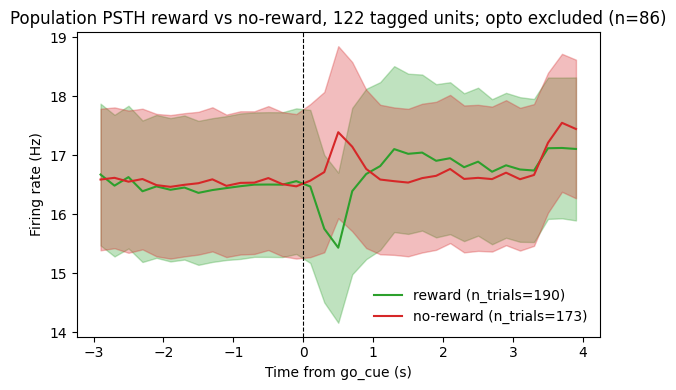

Population reward PSTH saved -> /root/capsule/scratch/raster_plot_tagged/863973_2026-08-25_14-18-29/population_psth_reward_vs_noreward.png


In [6]:
# =============================================================================
# 13. POPULATION-AVERAGE PSTH: reward vs no-reward (all tagged units)
# =============================================================================
from create_psth import load_psth_raster_subset

# Toggle: drop optogenetics (laser-on) trials from both groups.
EXCLUDE_OPTO = globals().get("EXCLUDE_OPTO", True)
_opto_excl = opto_trial_ids if EXCLUDE_OPTO else np.array([], dtype=np.int64)

# Reuse the population PSTH loaded above; fall back to loading if not present.
if "pop_psth" not in globals():
    pop_psth, _ = load_psth_raster_subset(
        psth, trial_ids=None, unit_ids=tagged_units,
        align_to_event=ALIGN_TO, time_window=TIME_WIN, consolidated=True,
    )
    trial_dim = next(d for d in pop_psth.dims if d.startswith("trial_"))
    trial_coord = next(c for c in pop_psth.coords if c.startswith("trial_index_"))
    times = pop_psth.coords["time"].values
    avail_ids = np.asarray(pop_psth.coords[trial_coord].values, dtype=np.int64)
    n_units = int(pop_psth.sizes["unit"])

# Reward groups: rewarded (either side) vs unrewarded (responded, no reward).
REWARD_GROUPS = {
    "reward": np.asarray(find_trials(nwb, "rewarded"), dtype=np.int64),
    "no-reward": np.asarray(find_trials(nwb, "unrewarded"), dtype=np.int64),
}
REWARD_GROUPS = {k: np.setdiff1d(v, _opto_excl, assume_unique=False) for k, v in REWARD_GROUPS.items()}
REWARD_GROUPS = {k: np.intersect1d(v, avail_ids, assume_unique=False) for k, v in REWARD_GROUPS.items()}

fig, ax = plt.subplots(figsize=(6, 4))
reward_colors = {"reward": "tab:green", "no-reward": "tab:red"}

for label, tids in REWARD_GROUPS.items():
    if tids.size == 0:
        print(f"skip: {label} (no trials)")
        continue
    sel = np.where(np.isin(avail_ids, tids))[0]
    sub = pop_psth.isel({trial_dim: sel})          # dims: unit, trial, time
    per_unit_mean = sub.mean(dim=trial_dim)        # dims: unit, time
    pop_mean = per_unit_mean.mean(dim="unit").values
    pop_sem = per_unit_mean.std(dim="unit").values / np.sqrt(max(n_units, 1))
    color = reward_colors.get(label, None)
    ax.plot(times, pop_mean, color=color, label=f"{label} (n_trials={tids.size})")
    ax.fill_between(times, pop_mean - pop_sem, pop_mean + pop_sem, color=color, alpha=0.3)

ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set_xlabel(f"Time from {ALIGN_TO} (s)")
ax.set_ylabel("Firing rate (Hz)")
excl_note = f"; opto excluded (n={len(opto_trial_ids)})" if (EXCLUDE_OPTO and len(opto_trial_ids)) else ""
ax.set_title(f"Population PSTH reward vs no-reward, {n_units} tagged units{excl_note}")
ax.legend(frameon=False)
fig.tight_layout()

POP_REWARD_PATH = OUTDIR / "population_psth_reward_vs_noreward.png"
fig.savefig(POP_REWARD_PATH, dpi=300, bbox_inches="tight")
plt.show()
print(f"Population reward PSTH saved -> {POP_REWARD_PATH}")